# Vectors and Embeddings

Object detection tells us *what* is in an image and *where* it is. But some questions require more:

- Is this face the same person we saw before?
- Which stored image is most similar to this new crop?
- Can I search by semantic similarity rather than exact pixel match?

Answering these questions requires a different representation. Instead of bounding boxes, we need a way to represent the *meaning* of an image as a number — or more precisely, as a list of numbers called a **vector**. This notebook builds that idea from the ground up: from basic vector arithmetic through distance metrics to CLIP embeddings on real images.

At the end we will also see how the same embedding idea applies to text — which opens the door to cross-modal search and language models.


## What is a Vector?

A **vector** is an ordered list of numbers. In NumPy it's just a 1-D array.
Geometrically it represents a point — or an arrow from the origin — in N-dimensional space.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# A 2-D vector
v = np.array([3.0, 2.0])
print(f'Vector: {v}   Shape: {v.shape}   Dtype: {v.dtype}')

# A 512-D vector — same concept, just not visualisable directly
big_v = np.random.randn(512)
print(f'High-dim vector shape: {big_v.shape}')

Vector: [3. 2.]   Shape: (2,)   Dtype: float64
High-dim vector shape: (512,)


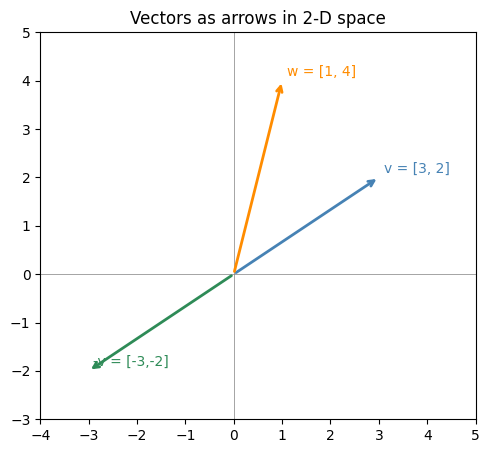

In [ ]:
# Visualise 2-D vectors as arrows from the origin
vectors = {
    'v = [3, 2]' : np.array([3, 2]),
    'w = [1, 4]' : np.array([1, 4]),
    '-v = [-3,-2]': np.array([-3, -2]),
}

fig, ax = plt.subplots(figsize=(5, 5))
colors = ['steelblue', 'darkorange', 'seagreen']
for (label, vec), color in zip(vectors.items(), colors):
    ax.annotate('', xy=vec, xytext=(0, 0),
                arrowprops=dict(arrowstyle='->', color=color, lw=2))
    ax.text(vec[0] + 0.1, vec[1] + 0.1, label, color=color, fontsize=10)
ax.axhline(0, color='grey', lw=0.5)
ax.axvline(0, color='grey', lw=0.5)
ax.set_xlim(-4, 5); ax.set_ylim(-3, 5)
ax.set_aspect('equal')
ax.set_title('Vectors as arrows in 2-D space')
plt.tight_layout()
plt.show()

## Distance Metrics

Given two vectors **a** and **b**, we can measure how far apart they are.
Two common metrics:

| Metric | Formula | When to prefer |
|--------|---------|----------------|
| **Euclidean** | $\\|a - b\\|_2 = \\sqrt{\\sum_i (a_i - b_i)^2}$ | When absolute magnitude matters |
| **Cosine similarity** | $\\frac{a \\cdot b}{\\|a\\| \\cdot \\|b\\|}$ | When only direction (angle) matters |

**Cosine similarity** ignores vector length — two identical vectors scaled by different amounts get similarity = 1.
This matters for embeddings: a brighter image should still be recognised as the same face.

In [ ]:
a = np.array([1.0, 2.0, 3.0])
b = np.array([1.0, 2.1, 2.9])  # slightly different
c = 5 * a                       # same direction as a, 5× longer

def euclidean(x, y):
    return np.sqrt(np.sum((x - y) ** 2))

def cosine_similarity(x, y):
    # Dot product divided by the product of their L2 norms.
    # Range: -1 (opposite) to 1 (identical direction).
    return np.dot(x, y) / (np.linalg.norm(x) * np.linalg.norm(y))

print(f'a vs b  — euclidean: {euclidean(a, b):.3f}  cosine: {cosine_similarity(a, b):.4f}')
print(f'a vs c  — euclidean: {euclidean(a, c):.3f}  cosine: {cosine_similarity(a, c):.4f}')
print()
print('a and c have the same direction → cosine similarity = 1.0 regardless of scale')

a vs b  — euclidean: 0.141  cosine: 0.9993
a vs c  — euclidean: 14.967  cosine: 1.0000

a and c have the same direction → cosine similarity = 1.0 regardless of scale


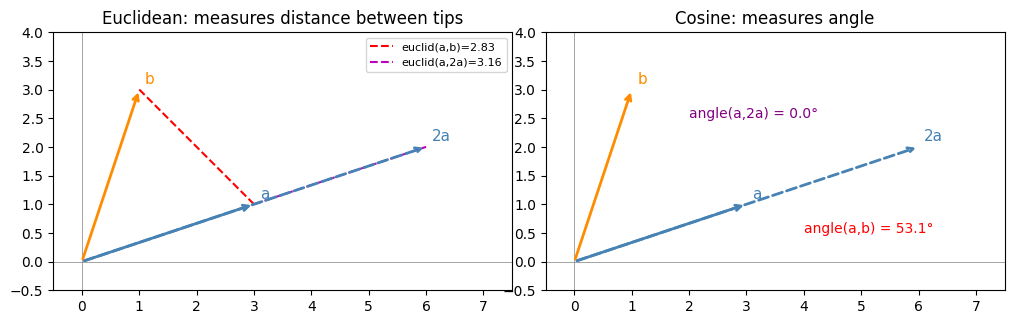

In [ ]:
# Visual demonstration: cosine measures angle, euclidean measures straight-line distance
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

points = {'a': np.array([3, 1]), 'b': np.array([1, 3]), '2a': np.array([6, 2])}
colors = {'a': 'steelblue', 'b': 'darkorange', '2a': 'steelblue'}
styles = {'a': '-', 'b': '-', '2a': '--'}

for label, vec in points.items():
    for ax in axes:
        ax.annotate('', xy=vec, xytext=(0, 0),
                    arrowprops=dict(arrowstyle='->', color=colors[label],
                                   lw=2, linestyle=styles[label]))
        ax.text(vec[0]+0.1, vec[1]+0.1, label, color=colors[label], fontsize=11)

a2, b2, two_a = points['a'], points['b'], points['2a']

# Euclidean: distance between tips
axes[0].plot([a2[0], b2[0]], [a2[1], b2[1]], 'r--', lw=1.5, label=f'euclid(a,b)={euclidean(a2,b2):.2f}')
axes[0].plot([a2[0], two_a[0]], [a2[1], two_a[1]], 'm--', lw=1.5, label=f'euclid(a,2a)={euclidean(a2,two_a):.2f}')
axes[0].set_title('Euclidean: measures distance between tips')
axes[0].legend(fontsize=8)

# Cosine: measures angle
angle_ab = np.degrees(np.arccos(np.clip(cosine_similarity(a2, b2), -1, 1)))
angle_a2a = np.degrees(np.arccos(np.clip(cosine_similarity(a2, two_a), -1, 1)))
axes[1].set_title('Cosine: measures angle')
axes[1].text(4, 0.5, f'angle(a,b) = {angle_ab:.1f}°', fontsize=10, color='red')
axes[1].text(2, 2.5, f'angle(a,2a) = {angle_a2a:.1f}°', fontsize=10, color='purple')

for ax in axes:
    ax.set_xlim(-0.5, 7.5); ax.set_ylim(-0.5, 4)
    ax.axhline(0, color='grey', lw=0.5); ax.axvline(0, color='grey', lw=0.5)
    ax.set_aspect('equal')

plt.tight_layout()
plt.show()

## What are Embeddings?

An **embedding** is a learned mapping from a high-dimensional input (image, text, audio)
to a dense low-dimensional vector in a **semantic space**.

The key property: inputs that are semantically similar are mapped to vectors that are **close**
in that space — as measured by cosine similarity or Euclidean distance.

```
Image of face A → [0.12, -0.34, 0.87, ...]  (512 numbers)
Image of face A (different lighting) → [0.11, -0.33, 0.85, ...]  ← very close!
Image of a car  → [-0.55,  0.21, 0.03, ...]  ← far away
```

This is why embeddings are used for face recognition: instead of comparing pixels
(which change drastically with lighting/angle), we compare **semantic representations**.

## Image Embeddings with CLIP

**CLIP** (Contrastive Language-Image Pre-Training) is trained on a very large set of image-text pairs. Its key idea is not only that images become vectors, but that **images and text are mapped into the same semantic space**.

For this module, we mainly use the image side of CLIP:

`image -> CLIP -> 512-D vector`

That is enough for face recognition and image similarity search.

But it also points toward a later NLP connection:

- an image can be embedded,
- a text description can also be embedded,
- and both can be compared in a shared vector space.

We use `sentence-transformers` as a convenient wrapper around the CLIP encoder.

### How CLIP Works

CLIP (Contrastive Language-Image Pre-Training) was trained by OpenAI on 400 million image-text pairs scraped from the web. The training objective is **contrastive**: given a batch of N (image, text) pairs, the model is trained so that the N matching pairs have high cosine similarity and the N² - N non-matching pairs have low similarity.

The architecture has two separate encoders:

```
image  ──►  Vision Transformer (ViT-B/32)  ──►  512-D vector
                                                    ↑ same space
text   ──►  Transformer text encoder        ──►  512-D vector
```

`clip-ViT-B-32` means: vision backbone is a **ViT** (Vision Transformer), variant **B** (Base, ~86 M parameters), patch size **32×32** pixels.

A key property of the output vectors: they are **L2-normalised** (unit norm). This means dot product and cosine similarity are identical (since both norms are 1, the denominator of the cosine formula is 1). You can therefore compare CLIP embeddings with a simple dot product, which makes similarity lookups very efficient.

We use only the image encoder here. The text side becomes important when we discuss cross-modal search at the end of this notebook.


In [ ]:
from PIL import Image
import os
from sentence_transformers import SentenceTransformer

# Load the CLIP image encoder (downloads ~350 MB on first run)
clip_model = SentenceTransformer('clip-ViT-B-32')
print('Model loaded')
print(f'Output embedding dimension: {clip_model.get_sentence_embedding_dimension()}')

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: /home/avidaldo/.cache/huggingface/hub/models--sentence-transformers--clip-ViT-B-32/snapshots/327ab6726d33c0e22f920c83f2ff9e4bd38ca37f/0_CLIPModel
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
The image processor of type `CLIPImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


Model loaded
Output embedding dimension: None


In [ ]:
# Use local test images from the resources/images directory
paths = {
    'lena': 'resources/images/lenna.png',
    'baboon': 'resources/images/baboon.png',
    'pepper': 'resources/images/peppers.jpg',
}

for name, path in paths.items():
    print(f'Ready: {path}')

Ready: resources/images/lenna.png
Ready: resources/images/baboon.png
Ready: resources/images/peppers.jpg


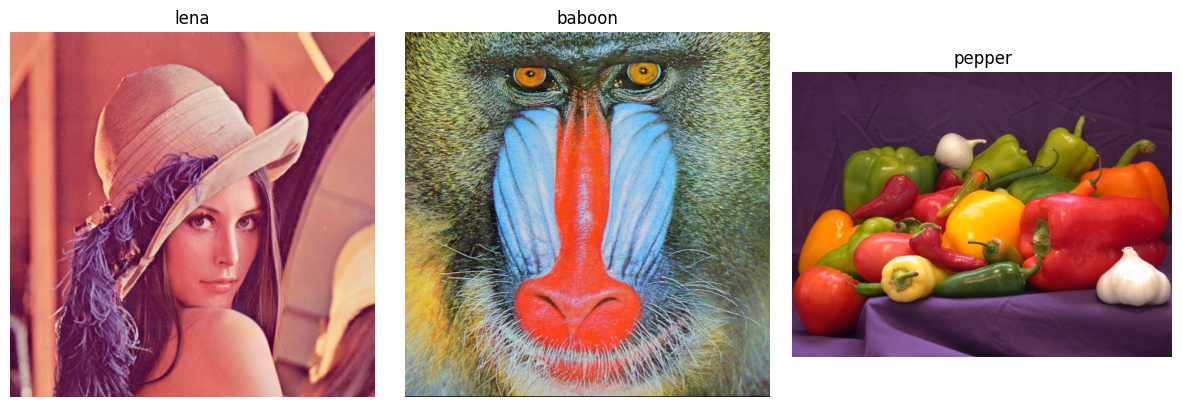

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, len(paths), figsize=(4 * len(paths), 4))
for ax, (name, path) in zip(axes, paths.items()):
    ax.imshow(Image.open(path).convert('RGB'))
    ax.set_title(name)
    ax.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
# Encode each image into a 512-D vector
embeddings = {}
for name, path in paths.items():
    img = Image.open(path).convert('RGB')
    # encode() accepts a PIL image or list of PIL images
    emb = clip_model.encode(img)    # returns a numpy array
    embeddings[name] = emb
    norm = np.linalg.norm(emb)      # L2 norm
    print(f'{name:10s}: shape={emb.shape}  norm={norm:.3f}  min={emb.min():.3f}  max={emb.max():.3f}')

lena      : shape=(512,)  norm=10.374  min=-6.494  max=2.064
baboon    : shape=(512,)  norm=10.683  min=-7.108  max=1.230
pepper    : shape=(512,)  norm=10.660  min=-6.466  max=1.454


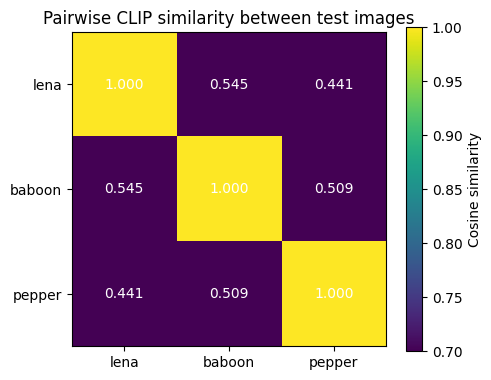

In [ ]:
# Compute pairwise cosine similarities
names = list(embeddings.keys())
n = len(names)
sim_matrix = np.zeros((n, n))

for i, ni in enumerate(names):
    for j, nj in enumerate(names):
        sim_matrix[i, j] = cosine_similarity(embeddings[ni], embeddings[nj])

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(sim_matrix, vmin=0.7, vmax=1.0, cmap='viridis')
ax.set_xticks(range(n)); ax.set_yticks(range(n))
ax.set_xticklabels(names); ax.set_yticklabels(names)
for i in range(n):
    for j in range(n):
        ax.text(j, i, f'{sim_matrix[i,j]:.3f}', ha='center', va='center', color='white', fontsize=10)
plt.colorbar(im, ax=ax, label='Cosine similarity')
ax.set_title('Pairwise CLIP similarity between test images')
plt.tight_layout()
plt.show()

## Visualising the Embedding Space with PCA

512 dimensions are impossible to visualise directly.
**PCA** (Principal Component Analysis) projects high-dimensional data to 2D while preserving
as much variance as possible — useful for quickly checking whether similar images cluster together.

Variance explained by 2 PCs: 100.0%


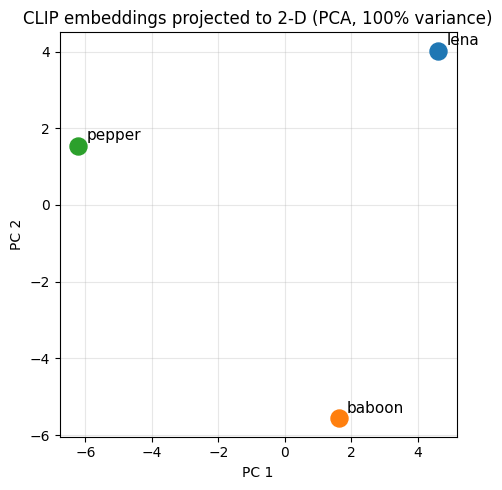

In [ ]:
from sklearn.decomposition import PCA

# Stack all embeddings into a matrix: shape (n_images, 512)
names_list = list(embeddings.keys())
X = np.stack([embeddings[n] for n in names_list])  # (3, 512)

# Project to 2D
pca = PCA(n_components=2)
X_2d = pca.fit_transform(X)   # (3, 2)

explained = pca.explained_variance_ratio_.sum() * 100
print(f'Variance explained by 2 PCs: {explained:.1f}%')

fig, ax = plt.subplots(figsize=(5, 5))
for i, name in enumerate(names_list):
    ax.scatter(*X_2d[i], s=150, zorder=3)
    ax.annotate(name, X_2d[i], textcoords='offset points', xytext=(6, 4), fontsize=11)
ax.set_title(f'CLIP embeddings projected to 2-D (PCA, {explained:.0f}% variance)')
ax.set_xlabel('PC 1'); ax.set_ylabel('PC 2')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Why Use Vectors for Face Recognition?

| Approach | Storage | Comparison | Scale |
|----------|---------|------------|-------|
| Raw pixels (512×512 RGB) | ~786 KB per face | pixel-by-pixel, slow | poor |
| Embedding (512 floats) | 2 KB per face | single dot product | excellent |

A cosine similarity between two 512-D vectors is just a dot product and two norms: a tiny amount of arithmetic. Comparing raw pixels requires hundreds of thousands of direct comparisons.

More importantly, embeddings are **robust**: the same person under different lighting, angle, or partial occlusion should map to nearby vectors. Pixel comparison would usually fail.

This is also the conceptual bridge to NLP. In later language models, sentences and documents are embedded for the same reason: not because the raw inputs look similar, but because they mean similar things.

The next notebook shows how to store these vectors and retrieve the nearest ones efficiently with a vector database.

## Embeddings in NLP: The Same Idea for Text

Everything we did above — encoding an object to a dense vector, measuring similarity with cosine distance, storing and searching in a database — applies equally to text.

In NLP, a **language model** maps a sentence or paragraph to a dense vector in a semantic space. Sentences that mean the same thing end up close; unrelated sentences end up far apart. The practice of searching a corpus by computing similarities against a query vector is called **semantic search**, and it is far more powerful than keyword matching.

The next code cell demonstrates this directly using the text side of the CLIP model that is already loaded.


In [ ]:
# CLIP maps text AND images to the same 512-D space.
# We can therefore compare a text query directly against image embeddings.
text_queries = [
    'a colourful image',
    'a human face',
    'a fruit or vegetable',
]

text_embeddings = clip_model.encode(text_queries)  # (3, 512)

print('Cosine similarity between text queries and images:')
print(f'{"":15} ' + ' '.join(f'{q[:12]:>14}' for q in text_queries))
for img_name, img_emb in embeddings.items():
    sims = [cosine_similarity(img_emb, text_embeddings[i]) for i in range(len(text_queries))]
    print(f'{img_name:15} ' + ' '.join(f'{s:14.3f}' for s in sims))


Cosine similarity between text queries and images:
                  a colourful    a human face   a fruit or v
lena                     0.244          0.208          0.191
baboon                   0.272          0.243          0.224
pepper                   0.244          0.179          0.266


The fact that text and image embeddings live in the same space is what makes **cross-modal search** possible: you can query an image database with a text description, or find documents related to a photo.

### Word Embeddings and Static Models

Before large language models, **word2vec** (Mikolov et al. 2013) and **GloVe** showed that individual words could be mapped to dense vectors with surprising geometric properties:

```
vector('king') - vector('man') + vector('woman')  ≈  vector('queen')
```

This analogy structure — now considered a simplification, but historically very influential — hinted that the geometry of a semantic space encodes real-world relationships.

### Contextual Embeddings and Transformers

Word2vec produces the same vector for a word regardless of context. BERT, GPT, and their successors introduced **contextual embeddings**: the same token gets a different vector depending on the sentence it appears in. This is essential for resolving ambiguity ('bank' as financial institution vs river bank).

### RAG: Retrieval-Augmented Generation

The connection between embeddings and language models reaches its current practical peak in **Retrieval-Augmented Generation (RAG)**:

1. A corpus of documents is encoded into vectors and stored in a vector database (like ChromaDB).
2. When a user sends a query, the query is encoded into a vector.
3. The most similar documents are retrieved from the database.
4. Those documents are injected into the context of a large language model.
5. The LLM generates a grounded answer that cites the retrieved content.

The retrieval step is exactly what is demonstrated in the ChromaDB notebook — only with images and face crops instead of text documents.

### The Core Insight

Whether the input is an image patch, a face crop, a word, or a sentence:

> **meaningful things that are semantically similar should be close in vector space**.

All the machinery in this module — CLIP encodings, cosine similarity, ChromaDB searches — is a direct application of this one idea.
